In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_solve
import scipy.optimize as opt
import random
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib
from sklearn.metrics import mean_squared_error
from scipy.linalg import cho_solve

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
Benedict_data = np.loadtxt('Benedict_Diamond.txt')
degree = 3

In [3]:
# idx = random.sample(range(Benedict_data.shape[0]-1), 10)
# idx
idx = [13, 42, 57, 33, 75, 52, 41, 9, 43, 69, 4, 82, 34, 93, 27, 63, 1, 40, 79,18]   # sample of 20 points

In [4]:
data = Benedict_data[idx,:]


In [5]:
# Experimental data

V_exp = np.array([4.20714967, 3.45613335, 3.98837788])
T_exp = np.array([1677.4818324 , 6191.47299911, 2373.53608845])

X_exp = np.hstack((V_exp.reshape(-1,1), T_exp.reshape(-1,1)))
y_exp = np.array([265, 599, 316]).reshape(-1,1)

In [6]:
X1 = np.vstack((data[:,0:2], X_exp))
X2 = data[:,0:2]
y1 = np.vstack((data[:,2].reshape(-1,1), y_exp))    # pressure
y2 = data[:,3].reshape(-1,1)                        # energy



In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X1)
X_P = scaler.transform(X1)
X_E = scaler.transform(X2)


scaler1 = MinMaxScaler()
y_P = scaler1.fit_transform(y1)
scaler2 = MinMaxScaler()

y_E = scaler2.fit_transform(y2)
y = np.concatenate((y_P, y_E))
y = y.reshape(-1,1)

In [8]:
def test(X, n_test):
    X1 = np.linspace(X[:,0].max(), X[:,0].min(), n_test)
    X2 = np.linspace(X[:, 0].min(), X[:,1].max(), n_test)
    X1P, X2P = np.meshgrid(X1, X2)
    X1E, X2E = np.meshgrid(X2, X1)
    X_testP = np.hstack((X1P.reshape(-1,1), X2P.reshape(-1,1)))
    X_testE = np.hstack((X2E.reshape(-1,1), X1E.reshape(-1,1)))
    return X_testP, X_testE


/var/folders/vd/pr68_4js7vnf535141p_blwc0000gn/T/ipykernel_93929/2575042551.py:3: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 11


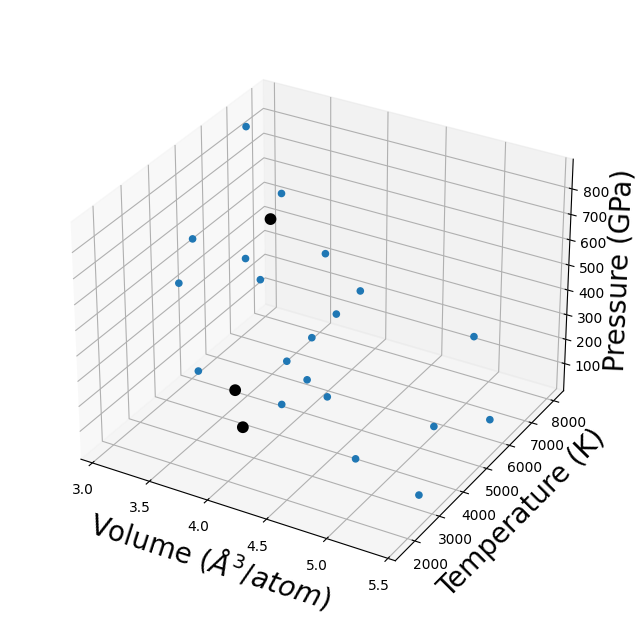

In [9]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.dist = 11
ax.scatter(X1[:,0], X1[:,1], y1, alpha=1)
ax.scatter(X_exp[:,0], X_exp[:,1], y_exp, marker="o", color = 'k', linewidths=4, alpha=1 )
ax.set_zlabel('Pressure (GPa)',fontsize=20)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=8)
plt.show()

/var/folders/vd/pr68_4js7vnf535141p_blwc0000gn/T/ipykernel_93929/194920412.py:3: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 11


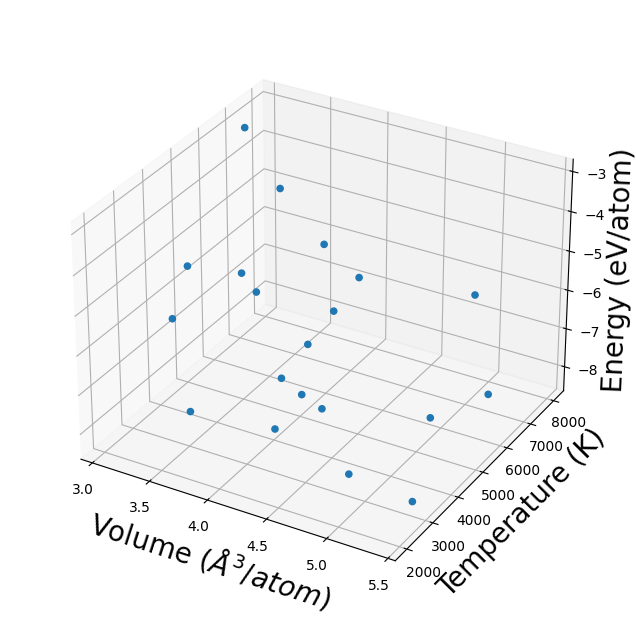

In [10]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.dist = 11
ax.scatter(X2[:,0], X2[:,1], y2, alpha=1)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20 , labelpad=8)
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=8)
ax.set_zlabel('Energy (eV/atom)',fontsize=20)
plt.show()

In [11]:
def poly_regression(x_train1, x_train2, y_train, x_test, degree):
    
    poly = PolynomialFeatures(degree)
    
    y_P = y_train[:x_train1.shape[0]]
    y_E = y_train[x_train1.shape[0]:]
    
    poly_train_P = poly.fit_transform(x_train1)
    poly_train_E = poly.fit_transform(x_train2)
    poly_test = poly.fit_transform(x_test)
    
    reg_P = LinearRegression().fit(poly_train_P, y_P)
    reg_E = LinearRegression().fit(poly_train_E, y_E)
    
    mu_P = reg_P.predict(poly_train_P)
    mu_E = reg_E.predict(poly_train_E)
    
    mu_test_P = reg_P.predict(poly_test)
    mu_test_E = reg_E.predict(poly_test)
    
    mu_regression = np.concatenate((mu_P,mu_E))      
    mu_test_regression = np.concatenate((mu_test_P,mu_test_E))
    
    return mu_regression, mu_test_regression



In [12]:
X_test,_ = test(X_P, n_test = 50)               # test points
X_c,_  = test(X_P, n_test = 10)                   # virtual points

In [13]:
mu_regression, mu_test_regression = poly_regression(X_P, X_E, y, X_test, degree)

In [14]:
rmse_Pressure = np.sqrt(mean_squared_error(y[:X_P.shape[0]], mu_regression[:y1.shape[0]]))
rmse_Energy = np.sqrt(mean_squared_error(y[X_P.shape[0]:], mu_regression[y1.shape[0]:]))
print(rmse_Pressure)
print(rmse_Energy)

0.005464317101810757
0.002257758946240763


In [15]:
def gradientFunction(x_train1, x_train2, y_train, n_test):
    
    X_testP, X_testE = test(x_train1, n_test)
    _ , mu_test_regression_P = poly_regression(x_train1, x_train2, y_train, X_testP, degree)
    _, mu_test_regression_E = poly_regression(x_train1, x_train2, y_train, X_testE, degree)
    
    
    y_pred_P = np.squeeze(mu_test_regression_P[:X_testP.shape[0]])
    y_pred_E = np.squeeze(mu_test_regression_E[X_testE.shape[0]:])
    gradP_V = np.gradient(y_pred_P, X_testP[:,0])
    gradE_T = np.gradient(y_pred_E, X_testE[:,1])
    
    return gradP_V, gradE_T

In [16]:
def poly_regression_prime(x_train1, x_train2, x_virtual, degree):
    
    gradP_V, gradE_T = gradientFunction(x_train1, x_train2, y, n_test = 30)
    X_testP, X_testE = test(x_train1, n_test= 30)
    
    poly = PolynomialFeatures(degree)
    
    y_P_prime = gradP_V.reshape(-1,1)
    y_E_prime = gradE_T.reshape(-1,1)
    
    poly_train_P = poly.fit_transform(X_testP)
    poly_train_E = poly.fit_transform(X_testE)
    
    poly_test = poly.fit_transform(x_virtual)
    
    reg_P = LinearRegression().fit(poly_train_P, y_P_prime)
    reg_E = LinearRegression().fit(poly_train_E, y_E_prime)
    
    
    mu_virtual_P = reg_P.predict(poly_test)
    mu_virtual_E = reg_E.predict(poly_test)
    
         
    mu_virtual_regression = np.concatenate((mu_virtual_P,mu_virtual_E))
    
    return mu_virtual_regression



In [17]:
mu_virtual_regression = poly_regression_prime(X_P, X_E, X_test, degree=3)

In [18]:
def K11(x1, x2, l1, l2, sigma_f, sigma_n1):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2*theta[0] - 4*theta[0]**2 * sq_diff_x[:,:,0])

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n1)**2

In [19]:

def K22(x1, x2, l1, l2, sigma_f, sigma_n2):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    exp_term = np.exp(-np.sum(theta * sq_diff_x, axis=2))

    K = sigma_f**2 * (exp_term +
                      x1[:, 1][:, None] * exp_term * (2 * theta[1] * (x1[:, 1][:, None] - x2[:, 1][None, :])) +
                      x2[:, 1][None, :] * exp_term * (2 * theta[1] * (-x1[:, 1][:, None] + x2[:, 1][None, :])) +
                      x1[:, 1][:, None] * x2[:, 1][None, :] * exp_term * (2 * theta[1] - 4 * theta[1]**2 * sq_diff_x[:,:,1]))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n2)**2

In [20]:
def K21(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * (np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2 * theta[0] * (-x1[:, 0][:, None] + x2[:, 0][None, :])) -
                      x1[:, 1][:, None] * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0] * theta[1] * (x1[:, 0][:, None] - x2[:, 0][None, :]) * (x1[:, 1][:, None] - x2[:, 1][None, :])))

    return K

In [21]:
def K12(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * (np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2 * theta[0] * (x1[:, 0][:, None] - x2[:, 0][None, :])) -
                      x2[:, 1][None, :] * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0] * theta[1] * (x1[:, 0][:, None] - x2[:, 0][None, :]) * (x1[:, 1][:, None] - x2[:, 1][None, :])))

    return K

In [22]:
def Kblock(x1,x2,l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11(x1,x1,l1,l2,sigma_f, sigma_n1),K12(x1,x2,l1,l2,sigma_f)],[K21(x2,x1,l1,l2,sigma_f),K22(x2,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [23]:
def Kblock12(x1,x2, x_test, l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11(x1,x_test,l1,l2,sigma_f, sigma_n1),K12(x1,x_test,l1,l2,sigma_f)],[K21(x2,x_test,l1,l2,sigma_f),K22(x2,x_test,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [24]:
def Kblock21(x1, x2, x_test, l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11(x_test,x1,l1,l2,sigma_f, sigma_n1),K12(x_test,x2,l1,l2,sigma_f)],[K21(x_test,x1,l1,l2,sigma_f),K22(x_test,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [25]:
def K11prime(x1, x2, l1, l2, sigma_f, sigma_n1):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0]**2 * (-8 * theta[0] * sq_diff_x[:,:,0] + (2 * theta[0] * sq_diff_x[:,:,0] - 1)**2 + 2))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n1)**2

In [26]:
def K12prime(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x2[:, 1][None, :] * theta[0] * theta[1] * (2 * theta[0] * sq_diff_x[:,:,0] - 1) * (2 * theta[1] * sq_diff_x[:,:,1] - 1))

    return K

In [27]:
def K21prime(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x1[:, 1][:, None] * theta[0] * theta[1] * (2 * theta[0] * sq_diff_x[:,:,0] - 1) * (2 * theta[1] * sq_diff_x[:,:,1] - 1))

    return K

In [28]:
def K22prime(x1, x2, l1, l2, sigma_f, sigma_n2):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x1[:, 1][:, None] * x2[:, 1][None, :] * theta[1]**2 * (-8 * theta[1] * sq_diff_x[:,:,1] + (2 * theta[1] * sq_diff_x[:,:,1] - 1)**2 + 2))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n2)**2

In [29]:
def Kblock_prime(x1,x2,l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11prime(x1,x1,l1,l2,sigma_f, sigma_n1),K12prime(x1,x2,l1,l2,sigma_f)],[K21prime(x2,x1,l1,l2,sigma_f),K22prime(x2,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [30]:
def Kblock_prime12(x1,x2, x_test, l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11prime(x1,x_test,l1,l2,sigma_f, sigma_n1),K12prime(x1,x_test,l1,l2,sigma_f)],[K21prime(x2,x_test,l1,l2,sigma_f),K22prime(x2,x_test,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [31]:
def Kblock_prime21(x1,x2,x_test,l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11prime(x_test,x1,l1,l2,sigma_f, sigma_n1),K12prime(x_test,x2,l1,l2,sigma_f)],[K21prime(x_test,x1,l1,l2,sigma_f),K22prime(x_test,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [32]:
def mle(theta, x_train1, x_train2, y_train, mean_regression):
    
    l1,l2, sigma_f, sigma_n1, sigma_n2 = theta  
    n1 = x_train1.shape[0]
    n2 = x_train2.shape[0]      
    K = Kblock(x_train1, x_train2, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)   + np.eye(n1+n2)*1e-10
    L = np.linalg.cholesky(K)
    var = ((y_train - mean_regression).T @ (cho_solve((L, True), y_train - mean_regression))) 
    LnofDetK = 2*np.sum(np.log(np.abs(np.diag(L)))) 
    le = -(1/2)*var - 0.5*LnofDetK - ((n1+n2)/2)*np.log(2*np.pi)
    
    return -le.flatten()
        
        

In [33]:
def neglikelihood(theta):
    return mle(theta, X_P, X_E,y, mu_regression) 

In [34]:

def predict(theta, x_train1, x_train2, y_train, x_test):
    
    
    l1,l2, sigma_f, sigma_n1, sigma_n2 = theta
    n1 = x_train1.shape[0]
    n2 = x_train2.shape[0]
    mu_reg, mu_test_reg = poly_regression(x_train1, x_train2, y_train, x_test, degree)
        
    k12 = Kblock12(x_train1,x_train2, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)  
    k21 = Kblock21(x_train1,x_train2, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)
    k22 = Kblock(x_test, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) 
    K = Kblock(x_train1, x_train2, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) +  np.eye(n1+n2)*1e-10
    L = np.linalg.cholesky(K)

    y_gp = mu_test_reg + k21 @ (cho_solve((L, True), y_train - mu_reg))
    varr = k22 - k21 @ (cho_solve((L, True), k12))
    pred_var = varr.diagonal()
    pred_std = np.sqrt(pred_var)

      
    return y_gp.flatten(), pred_std.flatten()

In [35]:
def predict_prime(theta, x_train1, x_train2, y_train, x_test):
    
        l1,l2, sigma_f, sigma_n1, sigma_n2 = theta
        n1 = x_train1.shape[0]
        n2 = x_train2.shape[0]
        
        mu_test_reg = poly_regression_prime(x_train1, x_train2, x_test, degree)
        
        k12 = Kblock_prime12(x_train1,x_train2, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)  
        k21 = Kblock_prime21(x_train1,x_train2, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)
        k22 = Kblock_prime(x_test, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) 
        K = Kblock_prime(x_train1, x_train2, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) +  np.eye(n1+n2)*1e-10
        L = np.linalg.cholesky(K)

        y_gp = mu_test_reg 
        varr = k22 - k21 @ (cho_solve((L, True), k12))
        pred_var = varr.diagonal()
        pred_var1 = pred_var.flatten()
        pred_var1[pred_var1<0.0]=0.0

      
        return y_gp.flatten(), pred_var1

In [36]:

def predict_virtual(theta):
    return predict_prime(theta, X_P, X_E, y, X_c)

def nonneg_const(theta):
    yy,s = predict_virtual(theta)
    # ye,se = predict_eq(theta)
    y_prime_mean_P = yy[:X_c.shape[0]]
    y_prime_std_P = s[:X_c.shape[0]] 
    
    y_prime_mean_E = yy[X_c.shape[0]:]
    y_prime_std_E = s[X_c.shape[0]:] 

    const1 = y_prime_mean_P + 1.96*np.sqrt(y_prime_std_P)
    const2 = y_prime_mean_E - 1.96*np.sqrt(y_prime_std_E)
      
    # const1 = yy 
    # const2 = 0.03 - np.abs(y.T-ye)
    const = np.concatenate((-const1, const2))
    
    return const

In [37]:
def opti():
    
        n = 10
        lb = np.array([-2.0,-2.0, -2.0, -10.0, -10.0])
        r= np.random.standard_normal(size=(n,5))
        x0 = r + lb
        optipar = np.zeros((n, 5))
        optifun = np.zeros((n, 1))
        for i in range(n):
            print(i)
            res= opt.fmin_cobyla(neglikelihood, x0[i,:].T, nonneg_const,args=(), consargs=None, rhobeg=1.0, rhoend=0.0001, maxfun=1000, disp=True, catol=0.0002)
            optipar[i,:] = res
            print(optipar[i,:])
            optifun[i,:] = neglikelihood(res)
            print(optifun[i,:])
        theta = optipar[np.argmin(optifun)]
        
        return theta

In [38]:
thetaopt = opti()


0
[ -0.97782848  -1.17880936  -3.2860713  -11.07779308  -8.64989577]
   Normal return from subroutine COBYLA

   NFVALS =   90   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.778285E-01  -1.178809E+00  -3.286071E+00  -1.107779E+01  -8.649896E+00

[-178.23289276]
1
[ -0.97780042  -1.17880003  -3.28605284  -8.81809214 -10.30038823]
   Normal return from subroutine COBYLA

   NFVALS =  118   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.778004E-01  -1.178800E+00  -3.286053E+00  -8.818092E+00  -1.030039E+01

[-178.23289274]
2
[ -0.97787144  -1.17890067  -3.28625099 -10.65550616  -9.48781391]
   Normal return from subroutine COBYLA

   NFVALS =  125   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.778714E-01  -1.178901E+00  -3.286251E+00  -1.065551E+01  -9.487814E+00

[-178.23289364]
3
[ -0.97776184  -1.17885697  -3.2861646  -10.41209958 -10.75316404]
   Normal return from subroutine COBYLA

   NFVALS =  475   F =-1.782329E+02    MAXCV = 0.000000E+00
   X =-9.777618E-01  -1.17885

In [39]:
thetaopt 

array([ -0.97788928,  -1.17888854,  -3.28622721,  -9.77626687,
       -11.36181168])

In [40]:
y_pred, y_std = predict(thetaopt, X_P, X_E, y, X_test)

In [41]:
X_testP, X_testE = test(X_P, n_test=50)          # test points

In [42]:
y_pred_P_prime, y_varr_P_prime = predict_prime(thetaopt, X_P, X_E, y, X_testP)
y_pred_E_prime, y_varr_E_prime = predict_prime(thetaopt, X_P, X_E, y, X_testE)

In [43]:
consP = y_pred_P_prime[:X_testP.shape[0]] + 1.96*np.sqrt(y_varr_P_prime[:X_testP.shape[0]])
consE = y_pred_E_prime[X_testE.shape[0]:] - 1.96*np.sqrt(y_varr_E_prime[X_testE.shape[0]:])
consP[consP>0].size, consE[consE<0].size

(0, 0)

In [44]:
y11 = y_pred[:X_test.shape[0]].reshape(-1,1)
y22 = y_pred[X_test.shape[0]:].reshape(-1,1)
y33 = y_std[:X_test.shape[0]].reshape(-1,1)
y44 = y_std[X_test.shape[0]:].reshape(-1,1)

In [45]:

P_mean = scaler1.inverse_transform(y11)
E_mean = scaler2.inverse_transform(y22)
P_ub = scaler1.inverse_transform(y11+y33)
E_ub = scaler2.inverse_transform(y22+y44)

In [46]:
P_std = P_ub - P_mean
E_std = E_ub - E_mean

In [47]:
meanP = P_mean
meanE = E_mean
stdP =  P_std
stdE =  E_std

In [48]:
X_testP = scaler.inverse_transform(X_testP)
X_testE = scaler.inverse_transform(X_testE)

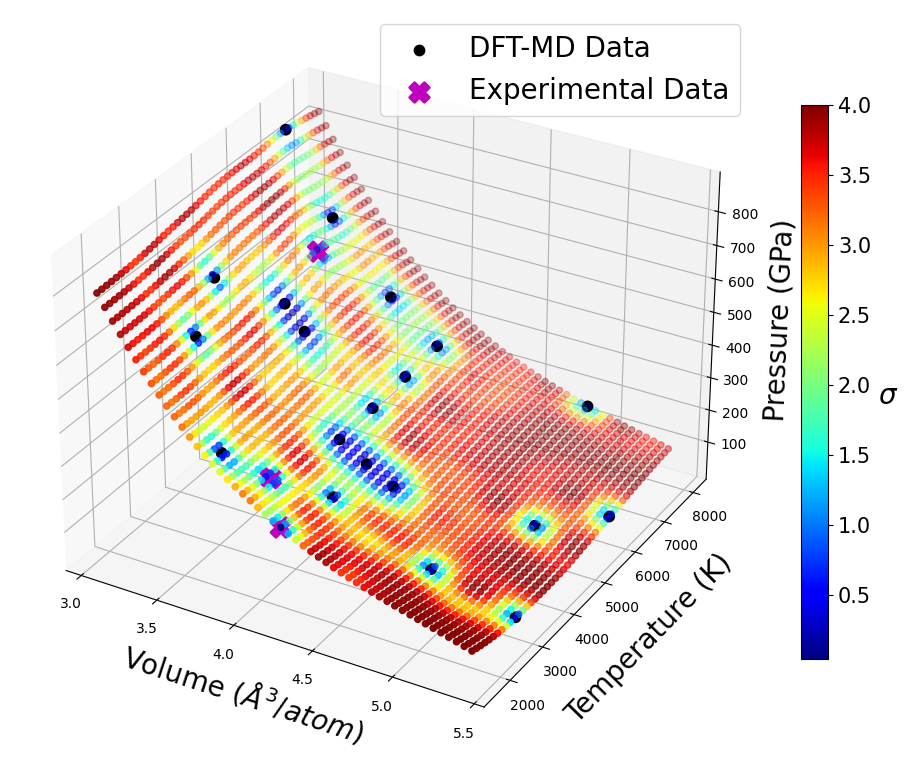

In [49]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p1 = ax.scatter(data[:,0], data[:,1], data[:,2], alpha=1, marker="o", color="k", linewidths=4, label="Simulation Data")
p2 = ax.scatter(X_exp[:,0], X_exp[:,1], y_exp, alpha=1, marker="X", color="m", s = 200, linewidths=2, label="Experimental Data")
p0 = ax.scatter(X_testP[:,0], X_testP[:,1], meanP ,c=stdP, cmap=plt.cm.jet, vmax = 4)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
# matplotlib.rc('ztick', labelsize=20)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=12)
ax.set_zlabel('Pressure (GPa)',fontsize=20, labelpad=9)
ax.legend(['DFT-MD Data', 'Experimental Data'], loc='upper right', fontsize =20)
# ax.fill_between(X_test[:,0], X_test[:,1], y_pred-1.96*np.sqrt(y_varr), 
#                 y_pred+1.96*np.sqrt(y_varr),
#                 facecolor='yellow',label='95% Credibility Interval')
cbar = fig.colorbar(p0, ax=ax, shrink = 0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20 , labelpad= 12)
cbar.ax.tick_params(labelsize=15)
plt.show()

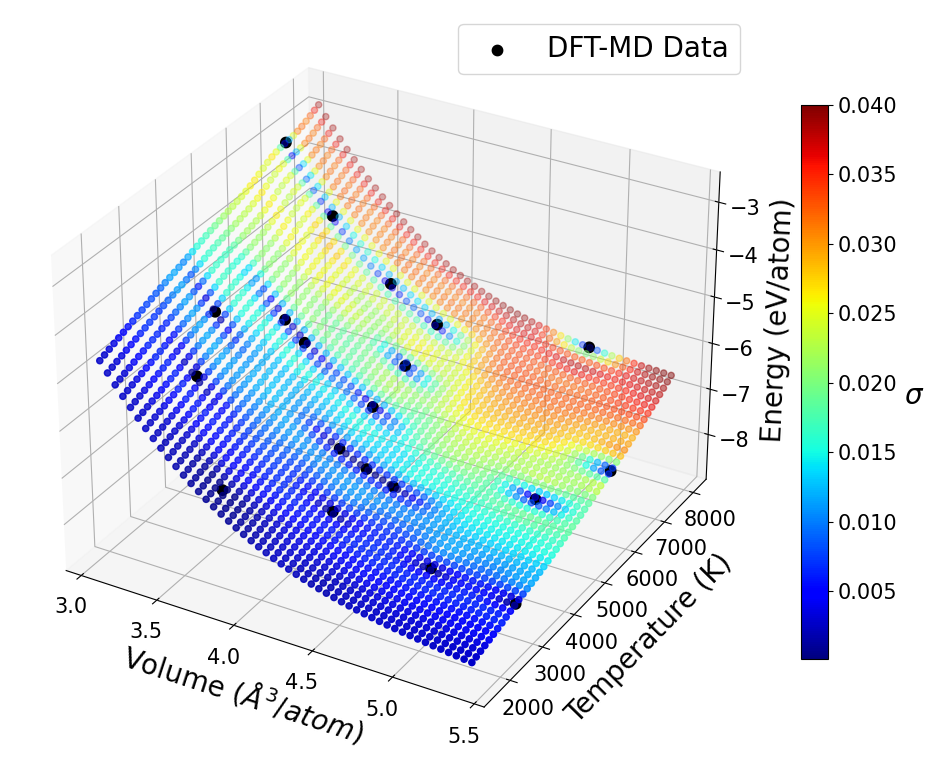

In [50]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(data[:,0], data[:,1], y2, alpha=1, marker="o", color="k", linewidths=4, label="Data")
p0 = ax.scatter(X_testP[:,0], X_testP[:,1], meanE ,c=stdE, cmap=plt.cm.jet, vmax=0.04)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
# matplotlib.rc('ztick', labelsize=20)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=12)
ax.set_zlabel('Energy (eV/atom)',fontsize=20, labelpad=8)
ax.legend(['DFT-MD Data'], loc='upper right', fontsize =20)
# ax.fill_between(X_test[:,0], X_test[:,1], y_pred-1.96*np.sqrt(y_varr), 
#                 y_pred+1.96*np.sqrt(y_varr),
#                 facecolor='yellow',label='95% Credibility Interval')
cbar = fig.colorbar(p0, ax=ax, shrink = 0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad=12)
cbar.ax.tick_params(labelsize=15)
plt.show()

In [51]:
t = np.linspace(1,2500,2500, dtype=int)

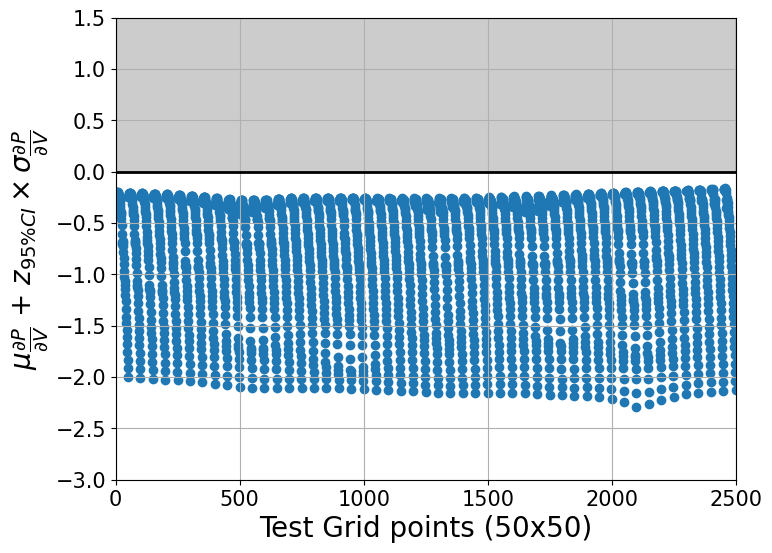

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(t,consP)
plt.axhline(y=0, color ='k', linewidth =2)
plt.ylabel(r'$\mu_{\dfrac{\partial P}{\partial V}}$ $+$ $z_{95\% CI} \times \sigma_{\dfrac{\partial P}{\partial V}}$', fontsize = 20)
plt.xlabel('Test Grid points (50x50)', fontsize = 20)
plt.xlim((0,2500))
plt.ylim((-3,1.5))
plt.tick_params(labelsize=15)
plt.fill_between(t, y1=0, y2 = 1.5, color='black', alpha=.2)
plt.grid()

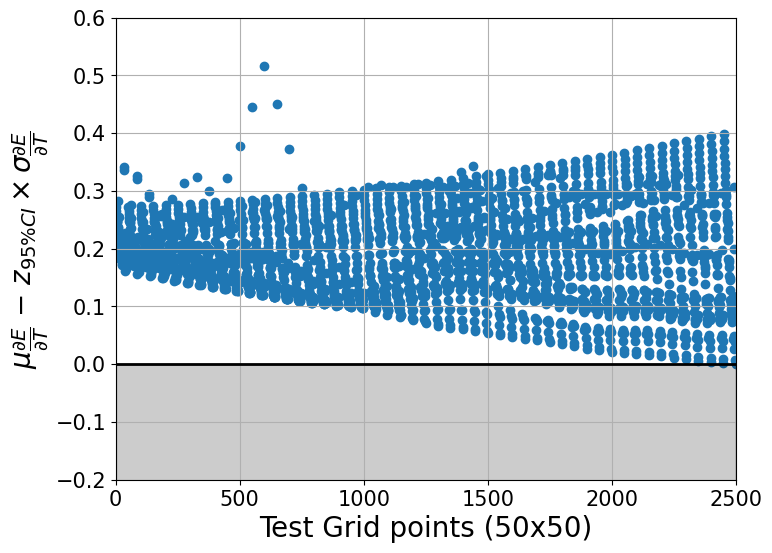

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(t, consE)
plt.axhline(y=0, color ='k', linewidth =2)
plt.ylabel(r'$\mu_{\dfrac{\partial E}{\partial T}}$ $-$ $z_{95\% CI} \times \sigma_{\dfrac{\partial E}{\partial T}}$', fontsize = 20)
plt.xlabel('Test Grid points (50x50)', fontsize = 20)
plt.xlim((0,2500))
plt.ylim((-0.20,0.6))
plt.tick_params( labelsize=15)
plt.fill_between(t, y1=0, y2 = -0.6, color='black', alpha=.2)
plt.grid()